M1: mu ~ N(0, I), y|mu ~ N(mu, I)
with MMD summary space regularization
D=20, N=100, S=4D

In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

INFO:bayesflow:Using backend 'tensorflow'


In [2]:
from tqdm.auto import tqdm as original_tqdm
import bayesflow.approximators.helpers.samplers as bf_samplers
import bayesflow.approximators.helpers.conditions as bf_conditions

def quiet_tqdm(*args, **kwargs):
    kwargs["disable"] = True
    return original_tqdm(*args, **kwargs)

bf_samplers.tqdm = quiet_tqdm
bf_conditions.tqdm = quiet_tqdm


In [3]:
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=100
mu_prior_mean=0
mu_prior_std=1
likelihood_std=1

In [4]:
# simulator
def prior(mu=mu_prior_mean, sigma=mu_prior_std):
    mu = RNG.normal(loc=mu, scale=sigma, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [5]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [6]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=4*num_dims, base_distribution="normal"
)

inference_net = bf.networks.CouplingFlow()

In [7]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=100
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [8]:
history = workflow.fit_online(epochs=epochs,batch_size=batch_size,num_batches_per_epoch=num_batches_per_epoch)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - CouplingFlow/loss: 26.0330 - DeepSet/loss: 0.3579 - loss: 26.3909
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - CouplingFlow/loss: 14.9089 - DeepSet/loss: 0.3456 - loss: 15.2546
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - CouplingFlow/loss: 5.3102 - DeepSet/loss: 0.3792 - loss: 5.6894
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - CouplingFlow/loss: -0.2543 - DeepSet/loss: 0.3698 - loss: 0.1155 
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - CouplingFlow/loss: -3.1408 - DeepSet/loss: 0.3388 - loss: -2.8020
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - CouplingFlow/loss: -5.1364 - DeepSet/loss: 0.3142 - loss: -4.8222
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - CouplingFlow/loss: -6.5567 - DeepSet/loss: 0.3011 - loss: -6.2556
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - CouplingFlow/loss: -7.7498 - DeepSet/loss: 0.2925 - loss: -7.4573
Epoch 9/100
128/128 ━━━

INFO:bayesflow:Training completed in 43.10 minutes.


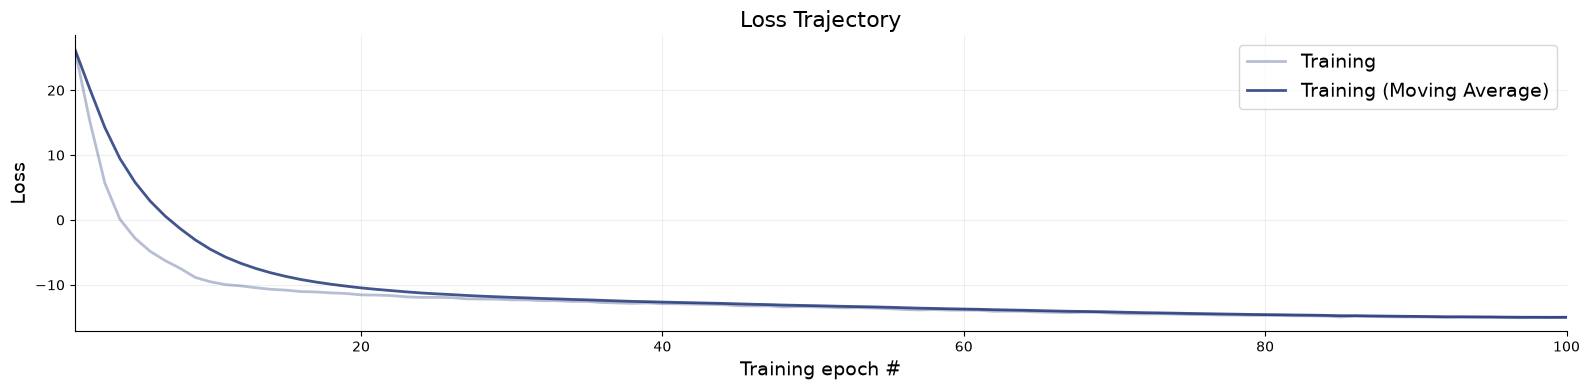

In [9]:
f=bf.diagnostics.plots.loss(history)

In [10]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


INFO:bayesflow:Sampling completed in 12.03 seconds.


dict_keys(['mu'])

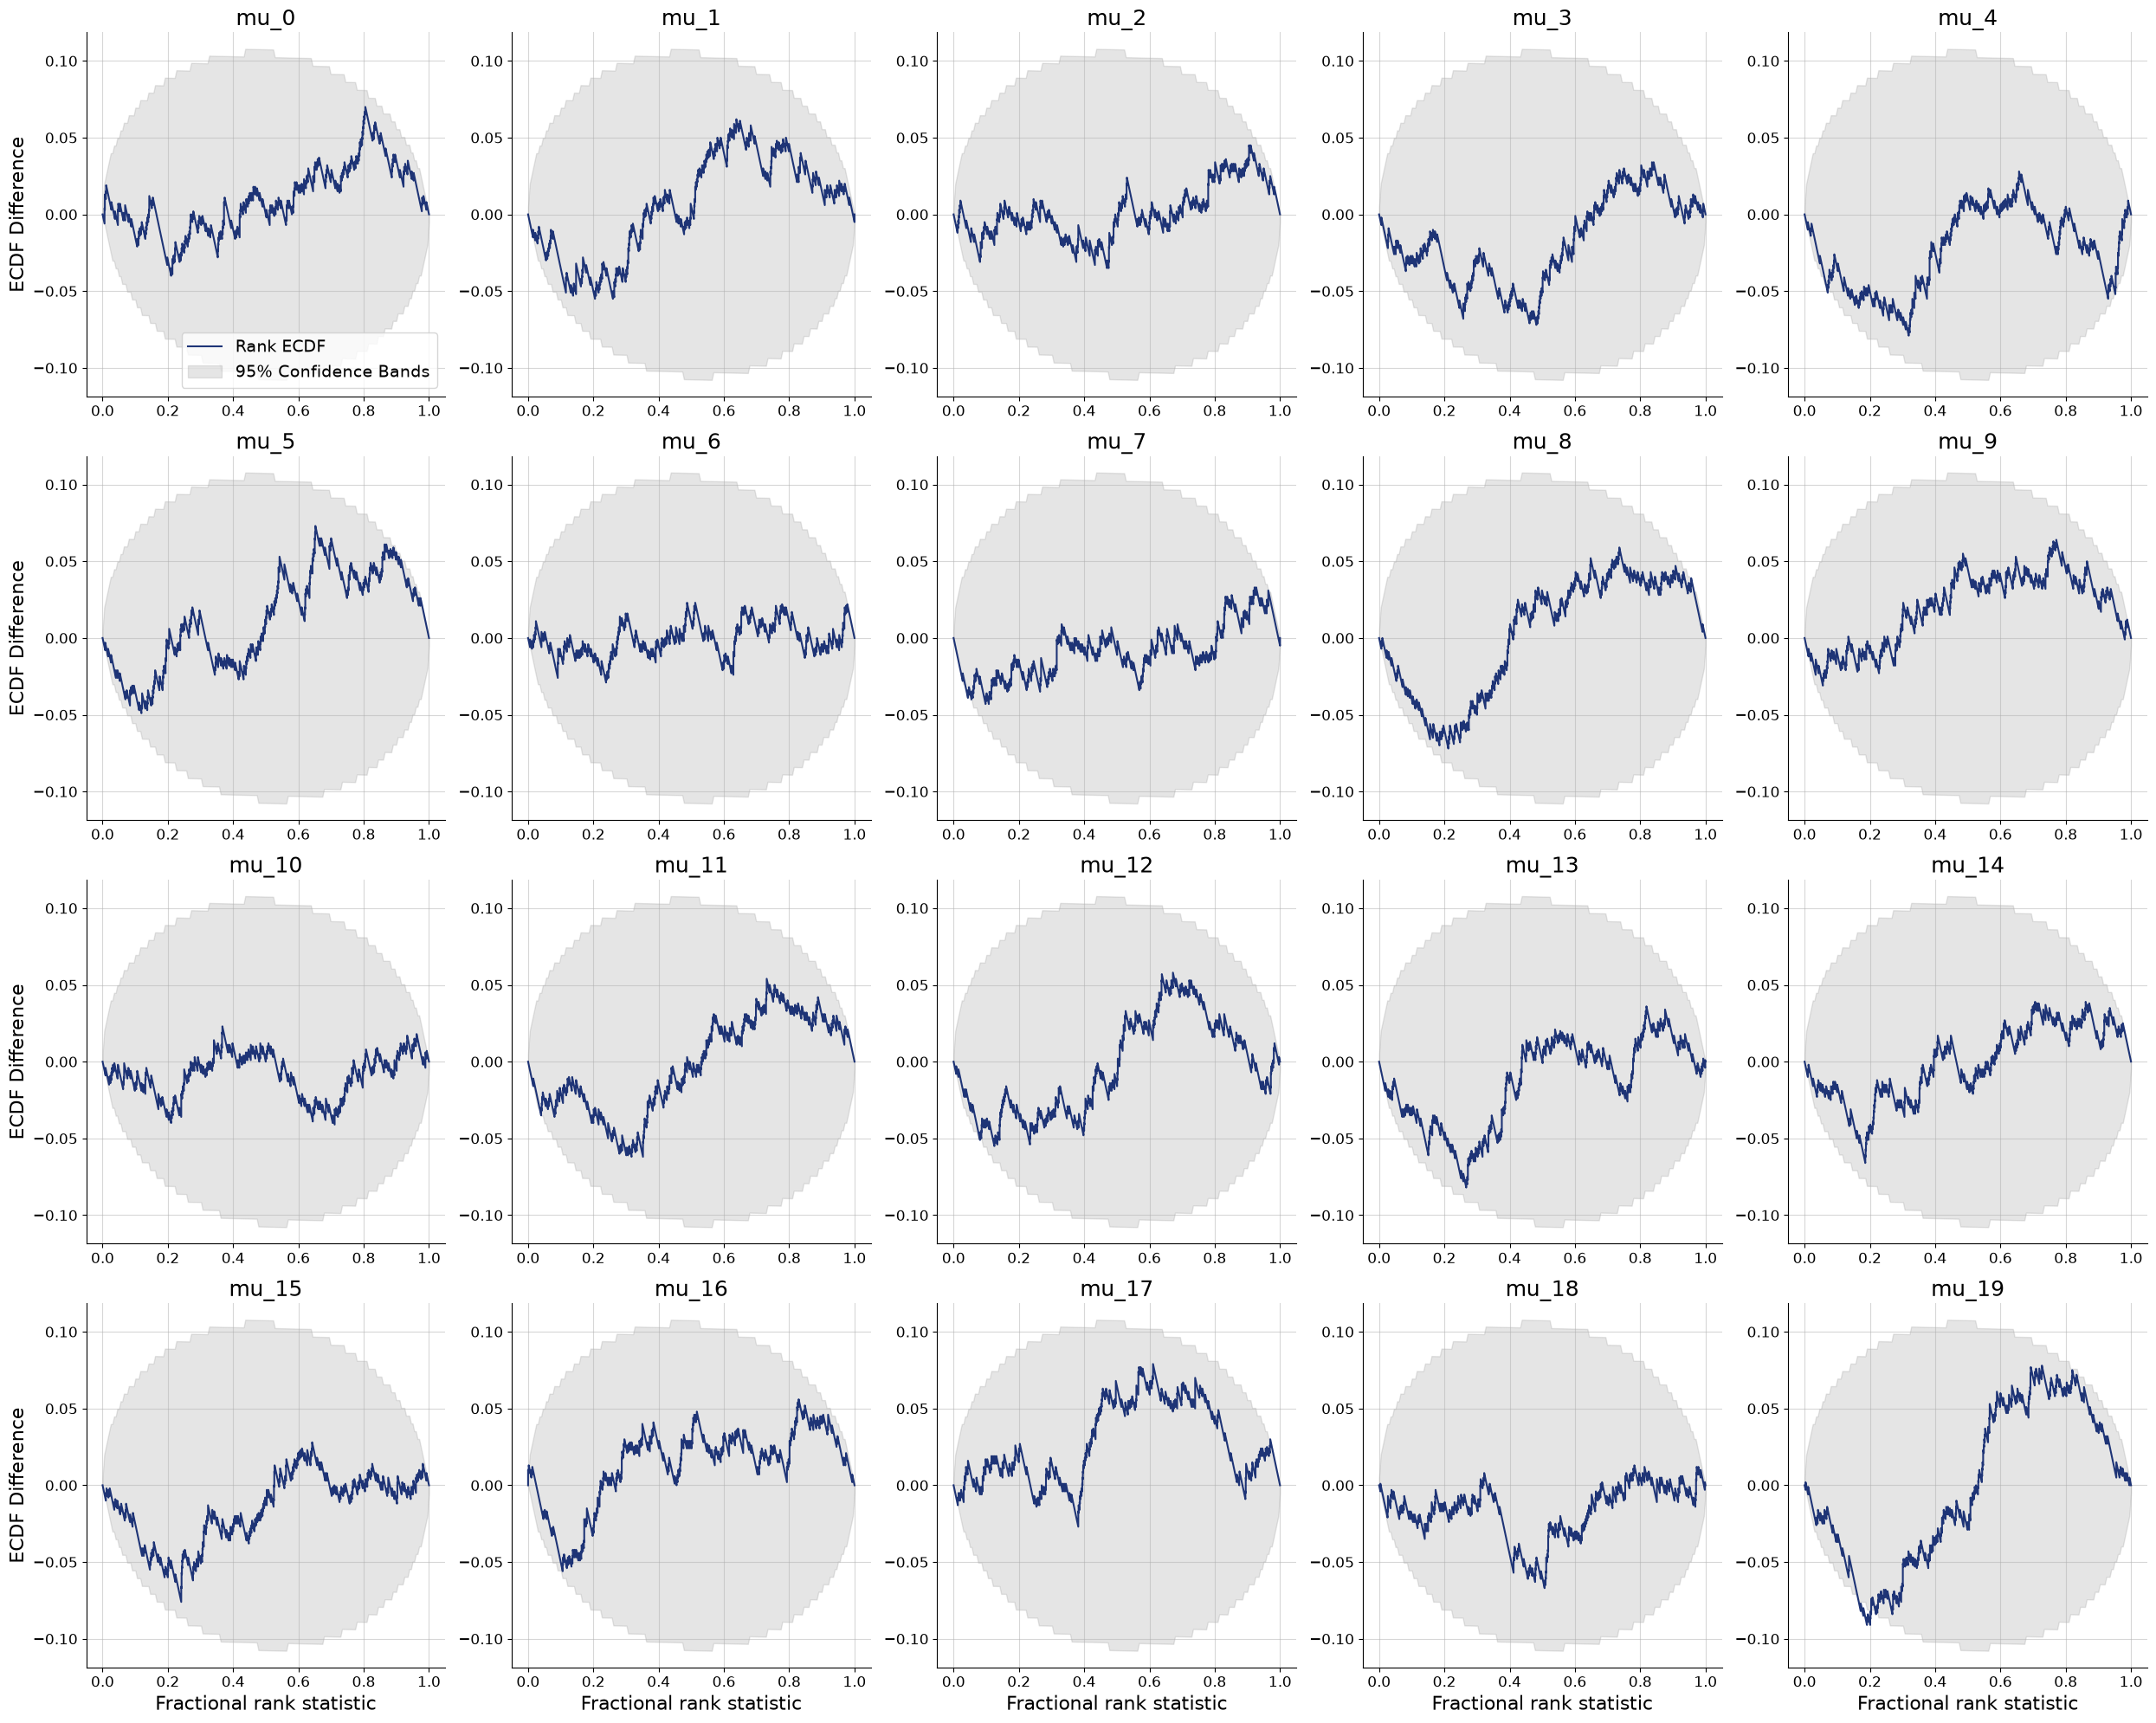

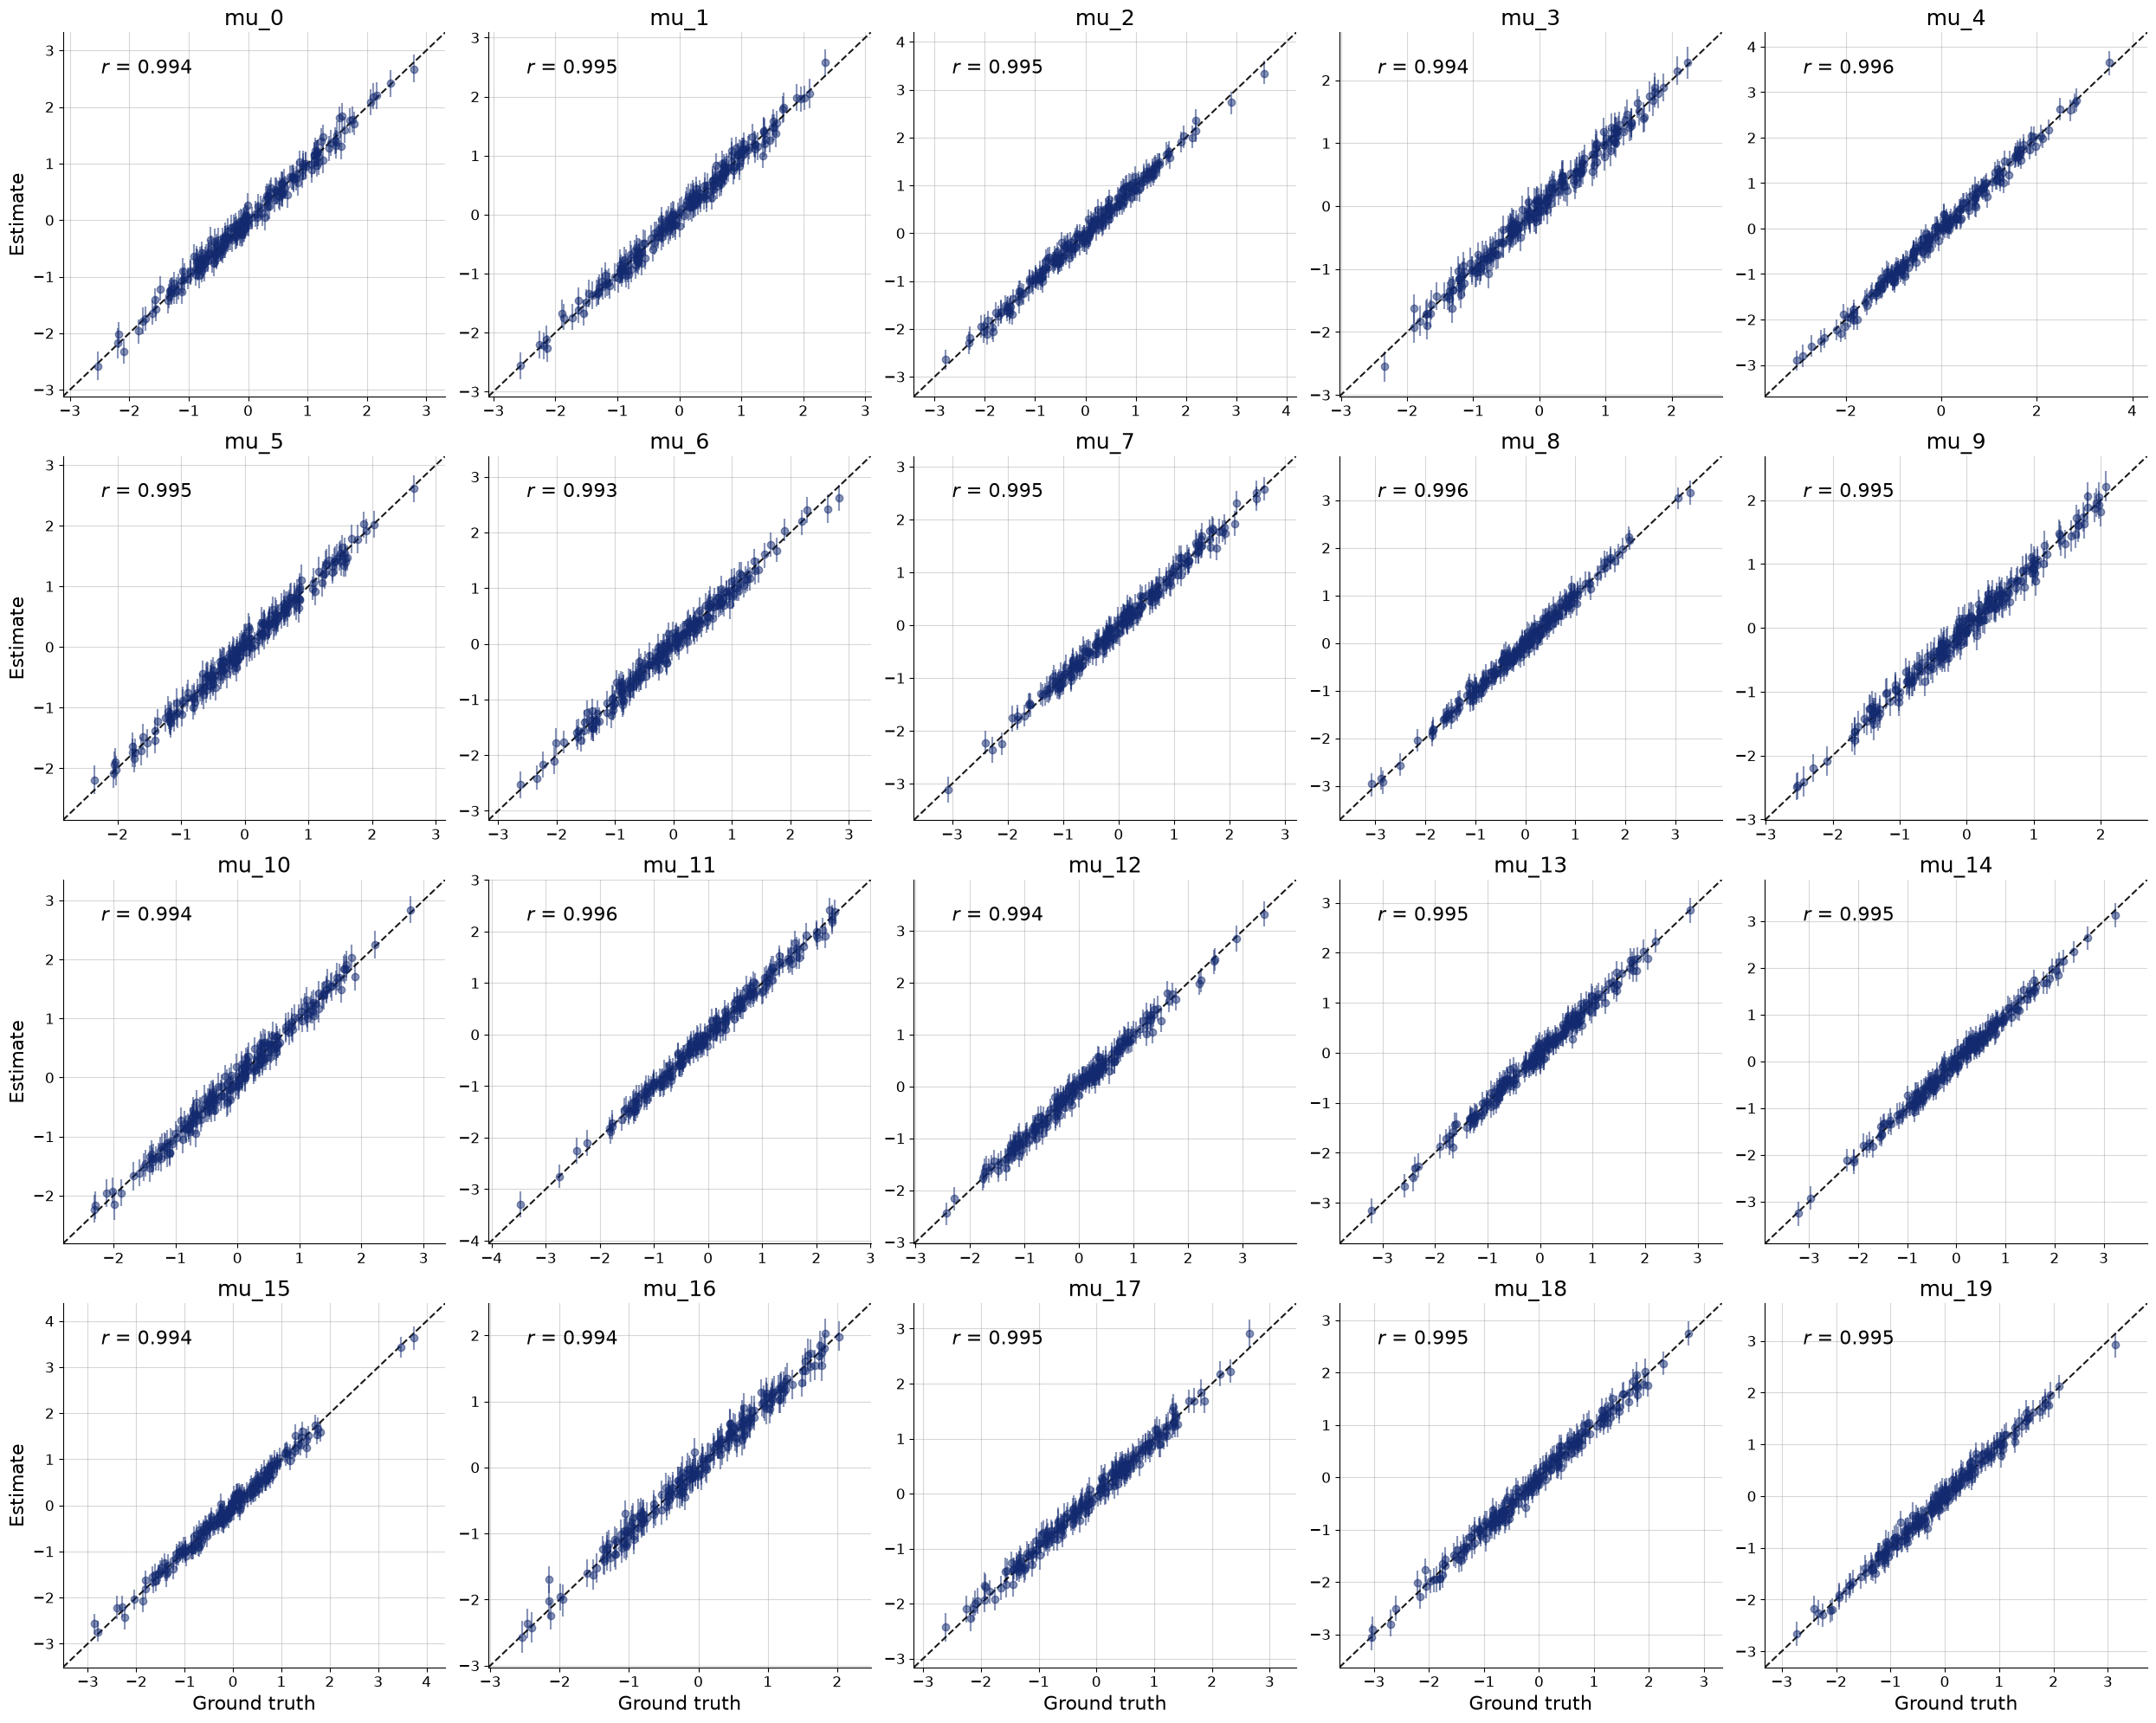

In [11]:
# f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [12]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks") / "m1_s_80d_100n.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [13]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/networks") / "m1_s_80d_100n.keras"
approximator = keras.saving.load_model(filepath)

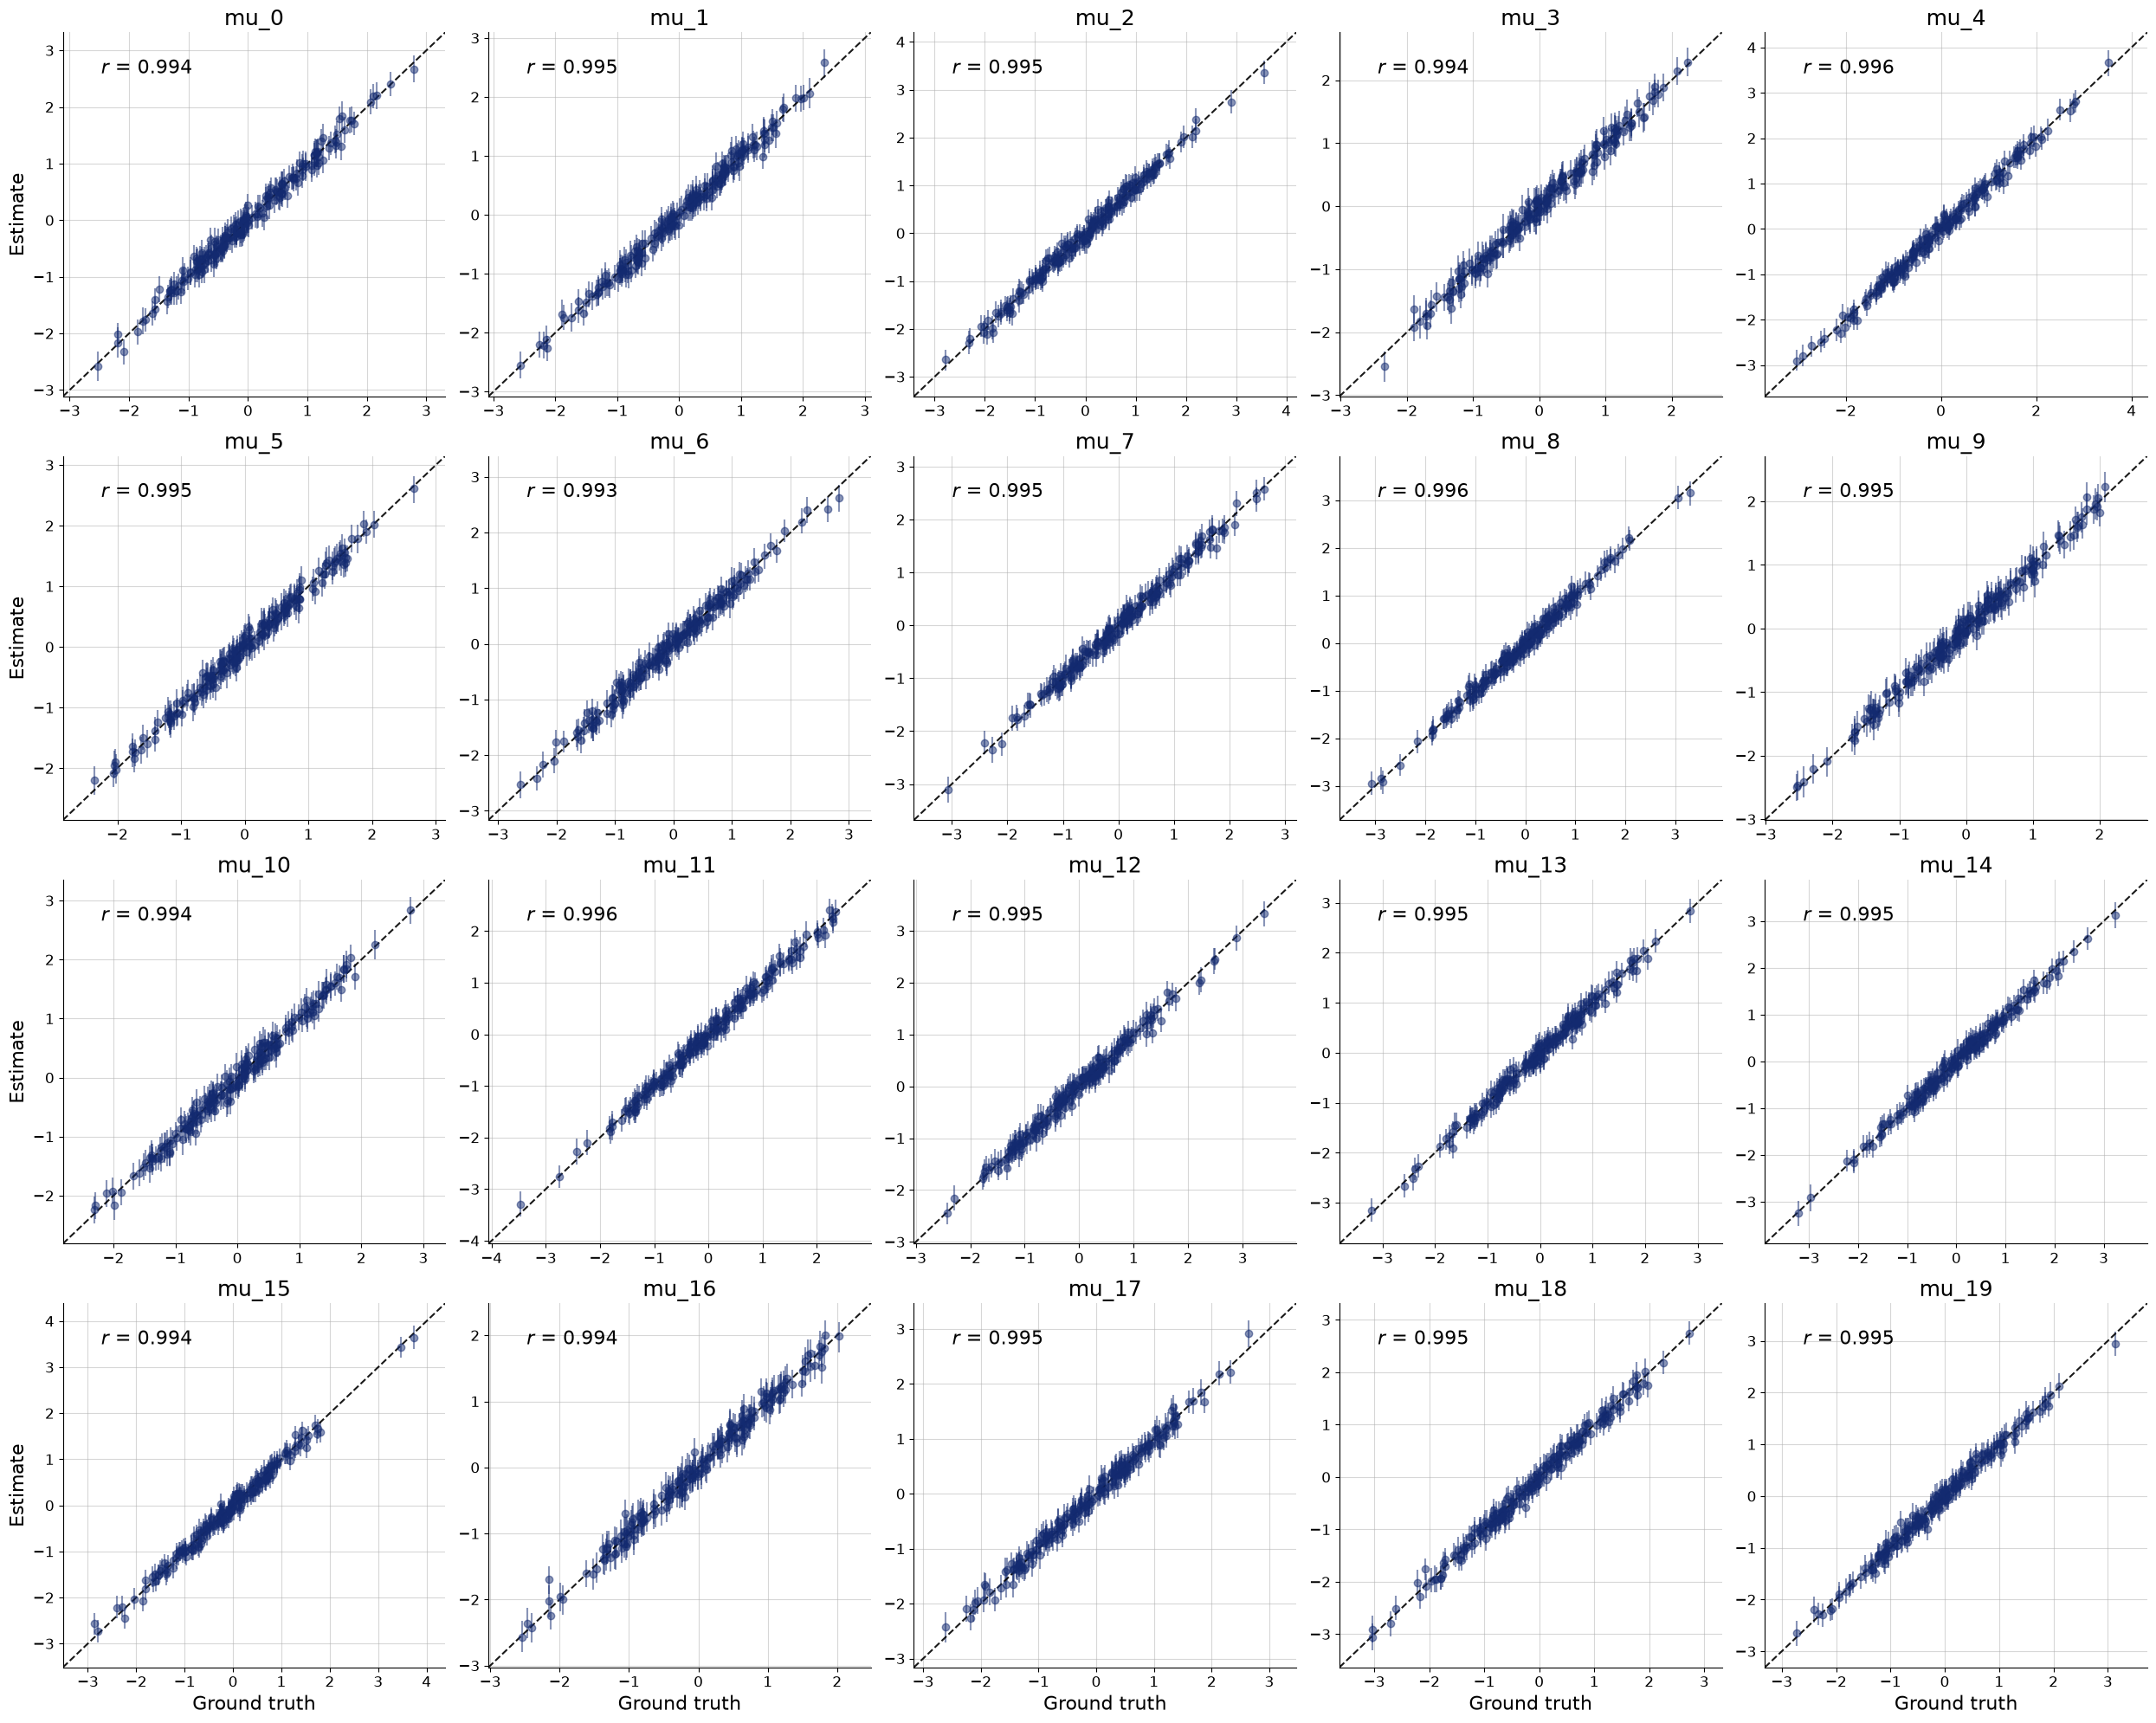

In [14]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)